PHASE 5 — Early-Warning Churn Analysis ( the most important part)


12. Identify Behavioral Signals( expand it into more depth)
•	Investigate declining usage, declining logins, declining engagement, increasing support tickets, payment failures, long inactivity periods, and declining satisfaction.
13. Create Early-Warning Features
•	Create usage_change_pct, login_change_pct, feature_adoption_change, support_ticket_change, engagement_trend, and days_since_last_login.
14. Identify Leading Indicators
•	Determine which behaviors are associated with future churn.
•	Important: association does not equal causation.
•	Tools: Python, Pandas, NumPy, SQL, Matplotlib.
•	Deliverable: 05_early_warning_analysis.ipynb

In [107]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Phase 5 - Early-Warning Churn Analysis

# Objective: Explore customer behavior and characteristics associated with churn

### Key Questions:
# 1. What characteristics are associated with higher churn?
# 2. How do churned and retained customer differ?
# 3. what behavioral patterns may help explain why customers churn?

In [ ]:
# Data files live in ../data/ (transactions_data.csv is not in the repo; see README)

In [ ]:
# Load CONFINFAD customers data
customer_df = pd.read_csv("../data/customer_data.csv")

print("Shape:", customer_df.shape)
print("Columns:", customer_df.columns.tolist())

print()
# Load the transaction dataset
transaction_df = pd.read_csv("../data/transactions_data.csv")

print("Original rows:", len(transaction_df))
print("Original unique customers:", transaction_df['customer_id'].nunique())
print("Columns:", transaction_df.columns.tolist())

Shape: (48723, 54)
Columns: ['customer_id', 'age', 'gender', 'location', 'income_bracket', 'occupation', 'education_level', 'marital_status', 'household_size', 'acquisition_channel', 'customer_segment', 'savings_account', 'credit_card', 'personal_loan', 'investment_account', 'insurance_product', 'active_products', 'app_logins_frequency', 'feature_usage_diversity', 'bill_payment_user', 'auto_savings_enabled', 'credit_utilization_ratio', 'international_transactions', 'failed_transactions', 'tx_count', 'avg_tx_value', 'total_tx_volume', 'first_tx', 'last_tx', 'base_satisfaction', 'tx_satisfaction', 'product_satisfaction', 'satisfaction_score', 'nps_score', 'last_survey_date', 'support_tickets_count', 'resolved_tickets_ratio', 'app_store_rating', 'feedback_sentiment', 'feature_requests', 'complaint_topics', 'clv_segment', 'monthly_transaction_count', 'average_transaction_value', 'total_transaction_volume', 'transaction_frequency', 'last_transaction_date', 'preferred_transaction_type', 'fir

In [ ]:
## make date an actual date, not a string
transaction_df['date'] = pd.to_datetime(transaction_df['date'])
transaction_df.dtypes

customer_id             int64
date           datetime64[ns]
amount                  int64
type                   object
dtype: object

In [ ]:
## Name window boundaries
cutoff= pd.Timestamp('2023-09-30')
print(cutoff)


2023-09-30 00:00:00


In [ ]:
## Split the transaction log into two subsets
feature_window_tnxns = transaction_df[transaction_df['date'] <= cutoff]
outcome_window_tnxns = transaction_df[transaction_df['date'] > cutoff]

print(feature_window_tnxns)
print(outcome_window_tnxns)

         customer_id       date   amount        type
1           93716481 2023-01-05   928900  Withdrawal
3           93716481 2023-04-14  4507350     Payment
4           93716481 2023-08-04  2096150     Payment
5           93716481 2023-03-29  2124050     Payment
6           93716481 2023-03-18  1108750    Transfer
...              ...        ...      ...         ...
3159152     41811965 2023-07-27  4907950    Transfer
3159153     41811965 2023-01-12  4683850    Transfer
3159154     41811965 2023-05-02  4093600    Transfer
3159155     41811965 2023-06-29  7078050    Transfer
3159156     41811965 2023-07-23  5438100    Transfer

[2367869 rows x 4 columns]
         customer_id       date   amount      type
0           93716481 2023-11-23  1262800  Transfer
2           93716481 2023-11-05  1683100   Payment
13          93716481 2023-11-16  1262350   Payment
18          93716481 2023-12-09   907800   Payment
19          93716481 2023-10-09   845550   Deposit
...              ...        ..

In [ ]:
## sannity check
len(feature_window_tnxns) + len(outcome_window_tnxns) == len(transaction_df)


True

In [ ]:
## Collapse each subset to onw row per customer

feature_window_tnxns.groupby('customer_id').size().sum()

feature_window_agg = feature_window_tnxns.groupby('customer_id').agg(
    Feature_Transaction_count = ('amount', 'count'),
    Feature_Total_amount =('amount', 'sum')
)

outcome_window_agg = outcome_window_tnxns.groupby('customer_id').agg(
    Outcome_Transaction_count = ('amount', 'count'),
    Outcome_Total_amount = ('amount','sum')
)


print(feature_window_agg)
print(outcome_window_agg)

             Feature_Transaction_count  Feature_Total_amount
customer_id                                                 
10000617                             6              39327200
10003212                             7              18143600
10004554                             6              24132250
10008981                            11              14959600
10011329                            16              10084950
...                                ...                   ...
99993890                            19               9370400
99995593                            34             154988200
99996571                            12              53850400
99996873                             9               9766300
99999798                            14             212961250

[48723 rows x 2 columns]
             Outcome_Transaction_count  Outcome_Total_amount
customer_id                                                 
10000617                             4              2121305

In [ ]:
## merging two tables

merged_df = pd.merge(feature_window_agg, outcome_window_agg, on='customer_id',how='outer').fillna(0)
print(merged_df)

             Feature_Transaction_count  Feature_Total_amount  \
customer_id                                                    
10000617                             6              39327200   
10003212                             7              18143600   
10004554                             6              24132250   
10008981                            11              14959600   
10011329                            16              10084950   
...                                ...                   ...   
99993890                            19               9370400   
99995593                            34             154988200   
99996571                            12              53850400   
99996873                             9               9766300   
99999798                            14             212961250   

             Outcome_Transaction_count  Outcome_Total_amount  
customer_id                                                   
10000617                           4.0   

In [ ]:
start_date = transaction_df['date'].min()
end_date = transaction_df['date'].max()

window_length = (end_date - start_date).days

feature_window_length = (cutoff - start_date).days

outcome_window_length = (end_date - cutoff).days

feature_window_rate = round(( merged_df['Feature_Transaction_count'] / feature_window_length ),2)

outcome_window_rate = round(( merged_df['Outcome_Transaction_count']/ outcome_window_length ),2)


print("start_date:", start_date)
print("end date:", end_date)
print("window length:", window_length)
print("feature_window_length:", feature_window_length)
print("outcome_window_length:", outcome_window_length)
print()
print(feature_window_rate)
print(outcome_window_rate)



start_date: 2023-01-04 00:00:00
end date: 2023-12-29 00:00:00
window length: 359
feature_window_length: 269
outcome_window_length: 90

customer_id
10000617    0.02
10003212    0.03
10004554    0.02
10008981    0.04
10011329    0.06
            ... 
99993890    0.07
99995593    0.13
99996571    0.04
99996873    0.03
99999798    0.05
Name: Feature_Transaction_count, Length: 48723, dtype: float64
customer_id
10000617    0.04
10003212    0.04
10004554    0.04
10008981    0.03
10011329    0.03
            ... 
99993890    0.02
99995593    0.23
99996571    0.03
99996873    0.03
99999798    0.01
Name: Outcome_Transaction_count, Length: 48723, dtype: float64


In [117]:
## the actual change metric

pct_change = (outcome_window_rate - feature_window_rate) / feature_window_rate

merged_df['enagement_change_pct'] = pct_change 
print(round(pct_change,2))
print(merged_df)

customer_id
10000617    1.00
10003212    0.33
10004554    1.00
10008981   -0.25
10011329   -0.50
            ... 
99993890   -0.71
99995593    0.77
99996571   -0.25
99996873    0.00
99999798   -0.80
Length: 48723, dtype: float64
             Feature_Transaction_count  Feature_Total_amount  \
customer_id                                                    
10000617                             6              39327200   
10003212                             7              18143600   
10004554                             6              24132250   
10008981                            11              14959600   
10011329                            16              10084950   
...                                ...                   ...   
99993890                            19               9370400   
99995593                            34             154988200   
99996571                            12              53850400   
99996873                             9               9766300   
999

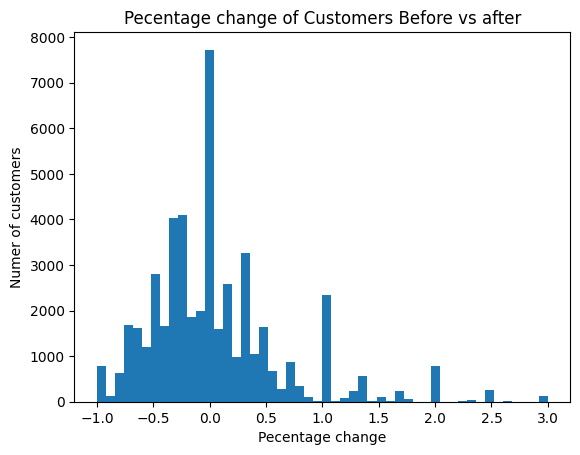

In [115]:
pct_change.describe()

pct_change.quantile([0.01, 0.05, 0.95, 0.99])

plt.hist(pct_change, bins= 50, range =(-1,3))

plt.title("Pecentage change of Customers Before vs after")
plt.xlabel("Pecentage change")
plt.ylabel("Numer of customers")
plt.show()

In [ ]:
## test thresholds
thresholds = [-0.3, -0.4, -0.5, -0.6]

for t in thresholds:
    pct = (pct_change <= t).mean()*100

    print(f"Threshold {t}: {pct:.2f}% of customers")
    
    print()

## -0.3 (29.6%): most inclusive, but risks catching normal month-to-month fluctuation as "decline," not real disengagement
## -0.4 (21.09%): the sweet spot — matches your historical baseline, moderate strictness
## -0.5 (17.86%): stricter, fewer false positives, but starts trimming real decliners
## -0.6 (11.31%): very strict — cleanest signal, but a smaller positive class to train a model on later in Phase 6


Threshold -0.3: 29.60% of customers

Threshold -0.4: 21.09% of customers

Threshold -0.5: 17.86% of customers

Threshold -0.6: 11.31% of customers



In [ ]:
## label column

merged_df['churned'] = pct_change <= -0.4
counts= merged_df['churned'].value_counts() 
Mean= merged_df['churned'].mean() * 100

print(counts)
print(round(Mean,2))


churned
False    38446
True     10277
Name: count, dtype: int64
21.09


In [ ]:
## days since last logins

last_tnx_in_feature_window = feature_window_tnxns.groupby('customer_id')['date'].max()
days_since_last_tnx = (cutoff - last_tnx_in_feature_window).dt.days

merged_df['last_tnx_in_feature_window'] = last_tnx_in_feature_window
merged_df['days_since_last_tnx'] = days_since_last_tnx
merged_df.describe()


,Feature_Transaction_count,Feature_Total_amount,Outcome_Transaction_count,Outcome_Total_amount,last_tnx_in_feature_window,days_since_last_tnx
count,48723.000000,4.872300e+04,48723.000000,4.872300e+04,48723,48723.000000
mean,48.598588,1.960112e+08,16.240543,6.146168e+07,2023-09-12 06:56:06.147405056,17.711040
min,2.000000,9.340000e+05,0.000000,0.000000e+00,2023-02-22 00:00:00,0.000000
25%,9.000000,1.514092e+07,3.000000,3.940825e+06,2023-09-06 00:00:00,3.000000
50%,14.000000,3.566355e+07,5.000000,1.023555e+07,2023-09-20 00:00:00,10.000000
75%,26.000000,9.133428e+07,9.000000,2.840518e+07,2023-09-27 00:00:00,24.000000
max,57871.000000,8.135142e+11,19594.000000,2.595732e+11,2023-09-30 00:00:00,220.000000
std,457.991205,4.713814e+09,153.996423,1.497524e+09,NaN,21.373985


In [ ]:
merged_df['Feature_Transaction_count'] > 1000
merged_df[merged_df['Feature_Transaction_count'] > 1000].sort_values('Feature_Transaction_count', ascending=False)


,Feature_Transaction_count,Feature_Total_amount,Outcome_Transaction_count,Outcome_Total_amount
customer_id,,,,
87831169,57871,813514164400,19594.0,2.595732e+11
41089287,27452,388572877750,9340.0,1.226970e+11
10435643,26531,15335996100,8968.0,4.848348e+09
79060117,20559,285866578750,6913.0,9.171492e+10
20318435,20298,290015136350,6893.0,9.105757e+10
...,...,...,...,...
39980263,1011,14427501850,365.0,4.749358e+09
80298812,1008,1619333200,348.0,5.642915e+08
29665209,1005,559280150,346.0,1.936386e+08


In [114]:
outlier_ids = merged_df[merged_df['Feature_Transaction_count'] > 1000].index
customer_df[customer_df['customer_id'].isin(outlier_ids)]['customer_segment'].value_counts()

customer_segment
occasional    97
regular       73
inactive      43
power         15
Name: count, dtype: int64

Note: A small number of accounts (~0.5%) show transaction volumes far above the typical customer and don't correlate with the customer_segment label — treated as a data quality note rather than investigated further given project scope

In [120]:
## Item 14: Identify Leading Indicators

merged_df.groupby('churned')['enagement_change_pct'].describe().round(2).T


churned,False,True
count,38446.00,10277.00
mean,0.26,-0.62
std,0.70,0.16
min,-0.40,-1.00
25%,-0.14,-0.75
50%,0.00,-0.60
75%,0.40,-0.50
max,10.00,-0.40


In [ ]:
## H0: There is no monotonic association between engagement change and churn.
## H1: There is a negative monotonic association between engagement change and churn (larger declines -> more churn).


from scipy.stats import spearmanr
correlation, p_value = spearmanr(
    merged_df['enagement_change_pct'],
    merged_df['churned'].astype(int)

)

print("Spearman correlation:", round(correlation,3))
print("P-value:", p_value)


Spearman correlation: -0.708
P-value: 0.0


In [126]:
## days_since_last_txn check

merged_df.groupby('churned')['days_since_last_tnx'].describe().round(2).T

churned,False,True
count,38446.00,10277.00
mean,17.60,18.14
std,21.98,18.92
min,0.00,0.00
25%,3.00,5.00
50%,9.00,12.00
75%,24.00,25.00
max,220.00,166.00


In [127]:
## H0: There is no monotonic association between days since last tnxt and churn.
## H1: There is a negative monotonic association between days since last tnxt  and churn (larger declines -> more churn).


from scipy.stats import spearmanr
correlation, p_value = spearmanr(
    merged_df['days_since_last_tnx'],
    merged_df['churned'].astype(int)

)

print("Spearman correlation:", round(correlation,3))
print("P-value:", p_value)


Spearman correlation: 0.064
P-value: 1.2811783886834656e-45


Days since last transaction was significantly but weakly associated with churn (Spearman's ρ = 0.064, p < 0.001). Churned customers had somewhat longer gaps since their last transaction (median 12 days vs. 9), consistent with the intuition that inactivity precedes disengagement — but the small effect size means this feature alone is not a strong predictor

In [139]:
## merging customer df with merged df

customer_df = customer_df.merge(merged_df[['churned']], left_on='customer_id', right_index=True, how='left')

print(customer_df)

       customer_id  age  gender                    location income_bracket  \
0         93716481   44    Male          Pereira, Risaralda      Very High   
1         49020929   44    Male       Cali, Valle del Cauca         Medium   
2         52690950   45    Male     Barranquilla, Atlántico           High   
3         23199751   45    Male        Bogotá, Cundinamarca           High   
4         61997066   44  Female        Bogotá, Cundinamarca         Medium   
...            ...  ...     ...                         ...            ...   
48718     58327025   30    Male  Cúcuta, Norte de Santander            Low   
48719     32505842   30  Female        Bogotá, Cundinamarca      Very High   
48720     97779703   29  Female          Pereira, Risaralda         Medium   
48721     11796475   29    Male        Bogotá, Cundinamarca         Medium   
48722     41811965   29  Female      Santa Marta, Magdalena         Medium   

                occupation education_level marital_status  hous

In [140]:
customer_df['churned'].isna().sum()

np.int64(0)

In [142]:
## satisfaction score check

customer_df.groupby('churned')['satisfaction_score'].describe().round(2).T

churned,False,True
count,38446.00,10277.00
mean,4.17,4.14
std,0.58,0.58
min,2.00,2.00
25%,4.00,4.00
50%,4.00,4.00
75%,5.00,4.00
max,6.00,6.00


In [153]:
## H0: There is no monotonic association between satisfaction score and churn.
## H1: There is a negative monotonic association between satisfaction score and churn (larger declines -> more churn).


from scipy.stats import spearmanr
correlation, p_value = spearmanr(
    customer_df['satisfaction_score'],
    customer_df['churned'].astype(int)

)

print("Spearman correlation:", round(correlation,3))
print("P-value:",p_value)


Spearman correlation: -0.018
P-value: 0.00011010627486340717


Note: Unlike the original dataset, where satisfaction_score was the strongest predictor found, satisfaction shows a negligible association with churn in this population (Spearman's ρ = -0.018, p < 0.001) — statistically detectable only due to the large sample size, with no practically meaningful relationship. This is also a whole-period aggregate that may include post-cutoff information, further limiting how much weight this result should carry

In [154]:
## support tickets count check

customer_df.groupby('churned')['support_tickets_count'].describe().round(2).T

churned,False,True
count,38446.0,10277.00
mean,1.0,0.99
std,1.0,1.00
min,0.0,0.00
25%,0.0,0.00
50%,1.0,1.00
75%,2.0,2.00
max,7.0,6.00


In [157]:
## H0: There is no monotonic association between support tickets count and churn.
## H1: There is a negative monotonic association between support ticket count and churn (larger declines -> more churn).


from scipy.stats import spearmanr
correlation, p_value = spearmanr(
    customer_df['support_tickets_count'],
    customer_df['churned'].astype(int)

)

print("Spearman correlation:", round(correlation,3))
print("P-value:",p_value)


Spearman correlation: -0.002
P-value: 0.7173405027050018


Note: Unlike the original dataset, where support ticket volume showed a weak but significant association with churn, no statistically significant relationship was found in this population (Spearman's ρ = -0.002, p = 0.72) — we fail to reject the null hypothesis here. As with the other static fields, this is also a whole-period aggregate subject to the same leakage caveat, though the lack of any signal makes that caveat largely moot in this case

In [159]:
## failed_transactions check

customer_df.groupby('churned')['failed_transactions'].describe().round(2).T

churned,False,True
count,38446.00,10277.00
mean,0.20,0.20
std,0.44,0.44
min,0.00,0.00
25%,0.00,0.00
50%,0.00,0.00
75%,0.00,0.00
max,4.00,4.00


In [161]:
## H0: There is no monotonic association between failed transactions and churn.
## H1: There is a negative monotonic association between failed transactions  and churn (larger declines -> more churn).


from scipy.stats import spearmanr
correlation, p_value = spearmanr(
    customer_df['failed_transactions'],
    customer_df['churned'].astype(int)

)

print("Spearman correlation:", round(correlation,3))
print("P-value:",p_value)

Spearman correlation: -0.0
P-value: 0.9485123691670809


Note: No association was found between payment failures and churn in this population (Spearman's ρ ≈ 0.00, p = 0.95) — we fail to reject the null hypothesis. This is a notable departure from the original dataset, where payment failures showed one of the clearer churn-risk patterns (churn rate rose from 19.2% to 50% across increasing failure counts).

In [163]:
## app_login_frequency check

customer_df.groupby('churned')['app_logins_frequency'].describe().round(2).T

churned,False,True
count,38446.00,10277.00
mean,22.35,22.47
std,11.72,11.87
min,4.00,4.00
25%,15.00,15.00
50%,22.00,22.00
75%,30.00,30.00
max,100.00,96.00


In [164]:
## H0: There is no monotonic association between app_logins_frequency and churn.
## H1: There is a negative monotonic association between app_logins_frequency and churn (larger declines -> more churn).


from scipy.stats import spearmanr
correlation, p_value = spearmanr(
    customer_df['app_logins_frequency'],
    customer_df['churned'].astype(int)

)

print("Spearman correlation:", round(correlation,3))
print("P-value:",p_value)

Spearman correlation: 0.003
P-value: 0.5514221363477558


Note: No statistically significant association was found between app login frequency and churn in this population (Spearman's ρ = 0.003, p = 0.55) — we fail to reject the null hypothesis. This contrasts with the original dataset, where login frequency showed a weak but significant negative association with churn (ρ = -0.065, p < 0.001). As with the other static fields, app_logins_frequency is a whole-period aggregate subject to the same leakage caveat noted throughout, though the complete absence of any signal here makes that caveat largely academic.

In [180]:
## Average transaction value trend
merged_df['Feature_Avg_amount'] = merged_df['Feature_Total_amount'] / merged_df['Feature_Transaction_count']
merged_df['Outcome_Avg_amount'] = merged_df['Outcome_Total_amount'] / merged_df['Outcome_Transaction_count']

count= merged_df['Outcome_Avg_amount'].isna().sum()
print("Feature avg amount:") 
print(merged_df['Feature_Avg_amount'])

print("Outcome avg amount:")
print(merged_df['Outcome_Avg_amount'])


print("count:", count)

Feature avg amount:
customer_id
10000617    6.554533e+06
10003212    2.591943e+06
10004554    4.022042e+06
10008981    1.359964e+06
10011329    6.303094e+05
                ...     
99993890    4.931789e+05
99995593    4.558476e+06
99996571    4.487533e+06
99996873    1.085144e+06
99999798    1.521152e+07
Name: Feature_Avg_amount, Length: 48723, dtype: float64
Outcome avg amount:
customer_id
10000617    5.303262e+06
10003212    1.314488e+06
10004554    2.906725e+06
10008981    2.075783e+06
10011329    5.186167e+05
                ...     
99993890    7.572500e+05
99995593    4.411957e+06
99996571    3.564117e+06
99996873    3.882550e+06
99999798    8.496350e+06
Name: Outcome_Avg_amount, Length: 48723, dtype: float64
count: 780


In [184]:
merged_df['Outcome_Avg_amount'] = merged_df['Outcome_Avg_amount'].fillna(0)

merged_df['avg_amount_change_pct'] = (merged_df['Outcome_Avg_amount'] - merged_df['Feature_Avg_amount']) / merged_df['Feature_Avg_amount']

count = merged_df['avg_amount_change_pct'].isna().sum()
print(merged_df['Outcome_Avg_amount'])

print(merged_df['avg_amount_change_pct'])

print(count)

customer_id
10000617    5.303262e+06
10003212    1.314488e+06
10004554    2.906725e+06
10008981    2.075783e+06
10011329    5.186167e+05
                ...     
99993890    7.572500e+05
99995593    4.411957e+06
99996571    3.564117e+06
99996873    3.882550e+06
99999798    8.496350e+06
Name: Outcome_Avg_amount, Length: 48723, dtype: float64
customer_id
10000617   -0.190902
10003212   -0.492856
10004554   -0.277301
10008981    0.526352
10011329   -0.177203
              ...   
99993890    0.535447
99995593   -0.032142
99996571   -0.205774
99996873    2.577911
99999798   -0.441453
Name: avg_amount_change_pct, Length: 48723, dtype: float64
0


In [185]:
## Avg transactio value check

merged_df.groupby('churned')['avg_amount_change_pct'].describe().round(2).T

churned,False,True
count,38446.00,10277.00
mean,-0.02,-0.09
std,0.39,0.67
min,-0.88,-1.00
25%,-0.26,-0.46
50%,-0.08,-0.19
75%,0.12,0.15
max,7.58,14.13


In [186]:
## H0: There is no monotonic association between avg transaction value and churn.
## H1: There is a negative monotonic association between avg transaction value and churn (larger declines -> more churn).


from scipy.stats import spearmanr
correlation, p_value = spearmanr(
    merged_df['avg_amount_change_pct'],
     merged_df['churned'].astype(int)

)

print("Spearman correlation:", round(correlation,3))
print("P-value:",p_value)

Spearman correlation: -0.119
P-value: 2.7127187644265717e-154


Note: Average transaction value showed a significant negative association with churn (Spearman's ρ = -0.119, p < 0.001) — the strongest non-circular signal found in this analysis. Churned customers' average transaction size declined more sharply (median -19% vs. -8%) and considerably more erratically (std 0.67 vs. 0.39) than retained customers, suggesting that shrinking and increasingly volatile transaction sizes may precede disengagement.

In [225]:
## The withdrawal-share-shift feature

## Step 1: Count withdrawals per customer, per window

feature_withdrawals = feature_window_tnxns[feature_window_tnxns['type'] == 'Withdrawal'].groupby('customer_id').size()
outcome_withdrawals = outcome_window_tnxns[outcome_window_tnxns['type'] == 'Withdrawal'].groupby('customer_id').size()

print("feature_withdrawals:", feature_withdrawals)
print( len(feature_withdrawals))
print("outcome_withdrawals:", outcome_withdrawals)
print(len(outcome_withdrawals))


feature_withdrawals: customer_id
10004554     1
10008981     2
10011329     2
10014787     2
10018179     2
            ..
99993053     4
99993509    28
99993890     5
99995593     5
99996571     3
Length: 41729, dtype: int64
41729
outcome_withdrawals: customer_id
10004554    1
10011329    2
10014787    1
10019156    1
10019675    1
           ..
99970321    1
99981846    2
99993053    1
99993509    8
99995593    1
Length: 27126, dtype: int64
27126


In [224]:
## step 2 merging two cols

merged_df['Feature_withdrawal_count'] = feature_withdrawals
merged_df['Outcome_withdrawal_count'] = outcome_withdrawals

merged_df['Feature_withdrawal_count'] = merged_df['Feature_withdrawal_count'].fillna(0)
merged_df['Outcome_withdrawal_count'] = merged_df['Outcome_withdrawal_count'].fillna(0)

count = merged_df[['Feature_withdrawal_count', 'Outcome_withdrawal_count']].isna().sum()

print(count)
print(merged_df['Feature_withdrawal_count'])
print(merged_df['Outcome_withdrawal_count'])

Feature_withdrawal_count    0
Outcome_withdrawal_count    0
dtype: int64
customer_id
10000617    0.0
10003212    0.0
10004554    1.0
10008981    2.0
10011329    2.0
           ... 
99993890    5.0
99995593    5.0
99996571    3.0
99996873    0.0
99999798    0.0
Name: Feature_withdrawal_count, Length: 48723, dtype: float64
customer_id
10000617    0.0
10003212    0.0
10004554    1.0
10008981    0.0
10011329    2.0
           ... 
99993890    0.0
99995593    1.0
99996571    0.0
99996873    0.0
99999798    0.0
Name: Outcome_withdrawal_count, Length: 48723, dtype: float64


In [223]:
## Step 3: Convert counts to shares
merged_df['Feature_withdrawal_share'] = merged_df['Feature_withdrawal_count'] / merged_df['Feature_Transaction_count']
merged_df['Outcome_withdrawal_share'] = merged_df['Outcome_withdrawal_count'] / merged_df['Outcome_Transaction_count']

count = merged_df['Outcome_withdrawal_share'].isna().sum()
merged_df['Outcome_withdrawal_share'] = merged_df['Outcome_withdrawal_share'].fillna(0)

print(merged_df['Feature_withdrawal_share'])
print(merged_df['Outcome_withdrawal_share'])
print(count)


customer_id
10000617    0.000000
10003212    0.000000
10004554    0.166667
10008981    0.181818
10011329    0.125000
              ...   
99993890    0.263158
99995593    0.147059
99996571    0.250000
99996873    0.000000
99999798    0.000000
Name: Feature_withdrawal_share, Length: 48723, dtype: float64
customer_id
10000617    0.000000
10003212    0.000000
10004554    0.250000
10008981    0.000000
10011329    0.666667
              ...   
99993890    0.000000
99995593    0.047619
99996571    0.000000
99996873    0.000000
99999798    0.000000
Name: Outcome_withdrawal_share, Length: 48723, dtype: float64
780


In [221]:
## Step 4: Compute the shift

merged_df['withdrawal_share_shift'] = merged_df['Outcome_withdrawal_share'] - merged_df['Feature_withdrawal_share']

print(merged_df['withdrawal_share_shift'])


customer_id
10000617    0.000000
10003212    0.000000
10004554    0.083333
10008981   -0.181818
10011329    0.541667
              ...   
99993890   -0.263158
99995593   -0.099440
99996571   -0.250000
99996873    0.000000
99999798    0.000000
Name: withdrawal_share_shift, Length: 48723, dtype: float64


In [220]:
## The withdrawal-share-shift featurecheck

churned_table = merged_df.groupby('churned')['withdrawal_share_shift'].describe().round(2).T


## H0: There is no monotonic association between withdrawal-share-shiftand churn.
## H1: There is a negative monotonic association between withdrawal-share-shiftand churn (draining account -> more churn).


from scipy.stats import spearmanr
correlation, p_value = spearmanr(
    merged_df['withdrawal_share_shift'],
     merged_df['churned'].astype(int)

)
print(churned_table)
print("Spearman correlation:", round(correlation,3))
print("P-value:",p_value)

churned     False     True 
count    38446.00  10277.00
mean        -0.00     -0.01
std          0.18      0.28
min         -0.80     -0.67
25%         -0.11     -0.18
50%          0.00     -0.09
75%          0.09      0.03
max          1.00      1.00
Spearman correlation: -0.125
P-value: 1.3823585722636362e-168


Note: Withdrawal share shift showed the strongest association with churn found in this analysis (Spearman's ρ = -0.125, p < 0.001), though in the opposite direction hypothesized: rather than an 'account draining' pattern of increasing withdrawals before churn, churned customers showed a median decrease in withdrawal share (-9 percentage points) versus no change for retained customers — suggesting withdrawals may drop out of a customer's transaction mix faster than other, more automated transaction types as overall engagement declines. As with the other features, churned customers also showed notably higher volatility (std 0.28 vs. 0.18).

### Signals Not Available in This Dataset

Several behavioral signals named in the Phase 5 outline could not be investigated for this population, due to the structure of the available data (transactions_data.csv and customer_data.csv):

- **Declining logins** and **login_change_pct**: no login event data exists anywhere in this dataset — only transaction records.
- **Declining satisfaction**: satisfaction_score, base_satisfaction, tx_satisfaction, and product_satisfaction are single snapshot values (one measurement per customer), not repeated measurements over time, so no before-vs-after comparison is possible.
- **feature_adoption_change**: feature_usage_diversity is a static whole-period total, not a time series.
- **support_ticket_change**: support_tickets_count is likewise a static whole-period total — only a snapshot-level association with churn could be tested (see the summary below), not a genuine trend.

These gaps reflect the dataset's structure, not a shortcut in the analysis — each was confirmed unavailable rather than assumed.

In [219]:
## Item 14 Summary: Leading Indicators

leading_indicators_summary = pd.DataFrame([
    {'Feature': 'enagement_change_pct', 'Spearman_rho': -0.708, 'P_value': 0.0, 'Verdict': 'Circular - used to define the churn label, not a genuine leading indicator'},
    {'Feature': 'withdrawal_share_shift', 'Spearman_rho': -0.125, 'P_value': 1.38e-168, 'Verdict': 'Strongest non-circular signal - direction opposite of hypothesized (withdrawal share drops, not rises, before churn)'},
    {'Feature': 'avg_amount_change_pct', 'Spearman_rho': -0.119, 'P_value': 2.71e-154, 'Verdict': 'Second-strongest non-circular signal - shrinking, more volatile transaction sizes precede churn'},
    {'Feature': 'days_since_last_tnx', 'Spearman_rho': 0.064, 'P_value': 1.28e-45, 'Verdict': 'Weak but real signal, sensible direction'},
    {'Feature': 'satisfaction_score', 'Spearman_rho': -0.018, 'P_value': 0.00011, 'Verdict': 'Statistically detectable, practically negligible'},
    {'Feature': 'app_logins_frequency', 'Spearman_rho': 0.003, 'P_value': 0.551, 'Verdict': 'Not significant'},
    {'Feature': 'support_tickets_count', 'Spearman_rho': -0.002, 'P_value': 0.717, 'Verdict': 'Not significant'},
    {'Feature': 'failed_transactions', 'Spearman_rho': 0.0, 'P_value': 0.949, 'Verdict': 'Not significant'},
])

leading_indicators_summary

,Feature,Spearman_rho,P_value,Verdict
0,enagement_change_pct,-0.708,0.000000e+00,"Circular - used to define the churn label, not..."
1,withdrawal_share_shift,-0.125,1.380000e-168,Strongest non-circular signal - direction oppo...
2,avg_amount_change_pct,-0.119,2.710000e-154,Second-strongest non-circular signal - shrinki...
3,days_since_last_tnx,0.064,1.280000e-45,"Weak but real signal, sensible direction"
4,satisfaction_score,-0.018,1.100000e-04,"Statistically detectable, practically negligible"
5,app_logins_frequency,0.003,5.510000e-01,Not significant
6,support_tickets_count,-0.002,7.170000e-01,Not significant
7,failed_transactions,0.000,9.490000e-01,Not significant


### Phase 5 Summary

Four genuine early-warning features were built from transactions_data.csv's chronological structure: **enagement_change_pct** (transaction-rate change, used to define the label itself), **avg_amount_change_pct** (average transaction size change), **withdrawal_share_shift** (change in the proportion of transactions that are withdrawals), and **days_since_last_tnx** (an inactivity measure analogous to days-since-last-login). These fed into a behaviorally-defined churn label (≥40% activity decline, yielding a 21.09% churn rate — consistent with the original Phase 1-4 baseline of 21.7%).

Of everything tested against this label, three features showed genuine, non-circular, statistically significant associations with churn: **withdrawal_share_shift** (ρ = -0.125, the strongest signal found — notably in the opposite direction hypothesized, with withdrawal share *dropping* rather than rising before churn), **avg_amount_change_pct** (ρ = -0.119 — shrinking, increasingly volatile transaction sizes precede churn), and **days_since_last_tnx** (ρ = 0.064, weaker but directionally sensible). None of the four static customer_data.csv fields tested (satisfaction_score, support_tickets_count, failed_transactions, app_logins_frequency) showed a meaningful relationship in this population, a notable departure from what the same variables showed in the original Phase 1-4 dataset. Several signals named in the outline (login trends, satisfaction trends, feature-adoption trends, support-ticket trends) could not be tested at all, since the dataset lacks repeated measurements for those variables.

As always: these are associations, not causal claims.

In [226]:
## Export feature table for Phase 6
## Combines the safe, non-circular features into one file: customer_df already
## has demographics, product holdings, the static behavioral fields, and the
## churned label merged in; this adds the four engineered features from merged_df.
## enagement_change_pct is included for reference only - NOT a model feature,
## since it was used to define the churned label itself. The other three
## (avg_amount_change_pct, withdrawal_share_shift, days_since_last_tnx) are safe,
## non-circular model features.

export_df = customer_df.merge(
    merged_df[['days_since_last_tnx', 'enagement_change_pct', 'avg_amount_change_pct', 'withdrawal_share_shift']],
    left_on='customer_id', right_index=True, how='left'
)

export_df.to_csv('../data/phase6_modeling_data.csv', index=False)
print("Exported:", export_df.shape)
export_df.head()

Exported: (48723, 59)


,customer_id,age,gender,location,income_bracket,occupation,education_level,marital_status,household_size,acquisition_channel,...,weekend_transaction_ratio,avg_daily_transactions,customer_tenure,churn_probability,customer_lifetime_value,churned,days_since_last_tnx,enagement_change_pct,avg_amount_change_pct,withdrawal_share_shift
0,93716481,44,Male,"Pereira, Risaralda",Very High,Engineer,Master,Married,5,Partnership,...,0.300000,0.030769,11.633333,0.362269,3.124148e+08,False,4,-0.136364,-0.452538,0.116650
1,49020929,44,Male,"Cali, Valle del Cauca",Medium,Construction Worker,Bachelor,Married,2,Paid Ad,...,0.181818,0.032934,11.500000,0.181790,1.670223e+08,False,37,-0.333333,-0.475427,-0.250000
2,52690950,45,Male,"Barranquilla, Atlántico",High,Construction Worker,Bachelor,Married,4,Paid Ad,...,0.300000,0.050000,8.766667,0.321265,1.940371e+07,False,16,0.000000,-0.318239,0.333333
3,23199751,45,Male,"Bogotá, Cundinamarca",High,Electrician,High School,Single,2,Referral,...,0.142857,0.047782,10.733333,0.336629,3.597811e+07,False,13,0.166667,-0.288743,-0.068627
4,61997066,44,Female,"Bogotá, Cundinamarca",Medium,Cleaner,Bachelor,Married,3,Paid Ad,...,0.315789,0.061889,11.633333,0.398151,3.046620e+08,False,33,-0.200000,-0.617676,-0.142857
